<a href="https://colab.research.google.com/github/KurniaYufi/nlp-sentiment-analisis/blob/main/Week1_Bibit_Scrapping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Week 1 - Scrapping Data Review Bibit**

Google Play Aplikasi Bibit : https://play.google.com/store/search?q=bibit&c=apps&hl=id

1. Instalasi dan Import Dependensi

Pada tahap awal, dilakukan instalasi pustaka google-play-scraper yang berfungsi untuk mengambil data dari Google Play Store. Selanjutnya, dilakukan pemanggilan (import) pustaka pendukung lainnya seperti Pandas dan Numpy untuk manipulasi tabel data, serta Matplotlib dan Seaborn untuk keperluan visualisasi grafik.

In [1]:
!pip install google_play_scraper

from google_play_scraper import app
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as dates
import seaborn as sns

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.1 MB/s eta 0:00:00


2. Scrapping Data


Proses pengambilan data dilakukan dengan menggunakan fungsi reviews_all untuk mengambil seluruh ulasan dari aplikasi Bibit (dengan ID paket com.bibit.bibitid). Data yang diambil disaring menggunakan parameter bahasa Indonesia dan diurutkan berdasarkan ulasan terbaru.

In [2]:
from google_play_scraper import app, Sort, reviews_all

bibit_reviews = reviews_all(
    'com.bibit.bibitid', # Google Play id for Bibit
    sleep_milliseconds=0,
    lang='id', # review language
    sort=Sort.NEWEST,
)

In [4]:
df_result = pd.DataFrame(np.array(bibit_reviews),columns=['content'])
df_result = df_result.join(pd.DataFrame(df_result.pop('content').tolist()))
df_result.to_csv(r'bibit_review.csv', index=False)
df_result

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,7e7dafb4-4bdb-47a5-a913-df0b6552231d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,KECEWA sudah nggk bisa pencairan instan (sesam...,1,0,3.107.0,2026-04-05 07:00:34,"Hai kak, terkait hal tersebut terdapat update ...",2026-04-05 20:38:22,3.107.0
1,71dbb877-abe4-4977-9321-aacbc2c9a2a1,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sangat bermanfaat buat menabung,5,0,3.107.0,2026-04-05 03:26:06,Terima kasih Kak Denny telah menjadi pengguna ...,2026-04-05 13:38:53,3.107.0
2,0dcb19fc-efb7-4da7-83e3-0aa09927ff08,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,saya sangat suka dimana bibit menjadi aplikasi...,4,0,3.106.2,2026-04-04 22:06:56,"Hai Kak Rizky, kami mohon maaf atas ketidaknya...",2026-04-05 13:38:32,3.106.2
3,80812a23-73e0-4633-811f-bdcba99a0db3,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,kenapa sekarang jatah Pencairan instan dibatas...,2,0,3.106.2,2026-04-04 13:47:36,Hai Kak Henry. Saat ini terdapat perubahan S &...,2026-04-05 13:36:37,3.106.2
4,e9545ada-5741-4afb-b846-6c3c52aba31b,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Gajelas, penambahn rekening baru gua ditolak, ...",1,0,3.107.0,2026-04-04 13:10:08,"Hai Kak Rapli, ketika tambah rekening, pastika...",2026-04-05 13:28:42,3.107.0
...,...,...,...,...,...,...,...,...,...,...,...
49104,0dc6339f-abba-43d9-afe5-746de3ddc4db,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"bgus nih aplikasi ,jdi lebih mudah pilih sama ...",5,2,None,2019-01-11 10:00:42,None,NaT,None
49105,3e96d1f4-a4ba-4d76-83b9-bf153bf07189,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Daripada taro duit di bank dimana bunga rendah...,5,4,1.1.0,2019-01-11 08:58:00,None,NaT,1.1.0
49106,fbcc0662-445c-4054-b446-77730664dfc9,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Design nya sangat bagus, dan membuat investasi...",5,4,1.1.0,2019-01-11 08:53:13,None,NaT,1.1.0
49107,8db8cabb-5722-4300-9954-2d62a2437a54,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Mantap bibit,5,0,1.1.0,2019-01-11 02:43:56,None,NaT,1.1.0


In [5]:
df_result.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49109 entries, 0 to 49108
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              49109 non-null  object        
 1   userName              49109 non-null  object        
 2   userImage             49109 non-null  object        
 3   content               49109 non-null  object        
 4   score                 49109 non-null  int64         
 5   thumbsUpCount         49109 non-null  int64         
 6   reviewCreatedVersion  42129 non-null  object        
 7   at                    49109 non-null  datetime64[ns]
 8   replyContent          10604 non-null  object        
 9   repliedAt             10604 non-null  datetime64[ns]
 10  appVersion            42129 non-null  object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 4.1+ MB


3. Pembersihan Dataframe Awal

Setelah data terkumpul dalam bentuk DataFrame, dilakukan proses perapian struktur data. Tahap ini mencakup pemecahan kolom 'content' yang berisi dictionary menjadi kolom-kolom terpisah, penyimpanan data ke format CSV (bibit_review.csv), dan penghapusan beberapa kolom yang dianggap tidak relevan untuk analisis.

In [6]:
# Selected Columns
df_analysis = df_result.loc[:,["content","score","thumbsUpCount", "reviewCreatedVersion", "at", "replyContent", "repliedAt"]]
df_analysis

,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,KECEWA sudah nggk bisa pencairan instan (sesam...,1,0,3.107.0,2026-04-05 07:00:34,"Hai kak, terkait hal tersebut terdapat update ...",2026-04-05 20:38:22
1,sangat bermanfaat buat menabung,5,0,3.107.0,2026-04-05 03:26:06,Terima kasih Kak Denny telah menjadi pengguna ...,2026-04-05 13:38:53
2,saya sangat suka dimana bibit menjadi aplikasi...,4,0,3.106.2,2026-04-04 22:06:56,"Hai Kak Rizky, kami mohon maaf atas ketidaknya...",2026-04-05 13:38:32
3,kenapa sekarang jatah Pencairan instan dibatas...,2,0,3.106.2,2026-04-04 13:47:36,Hai Kak Henry. Saat ini terdapat perubahan S &...,2026-04-05 13:36:37
4,"Gajelas, penambahn rekening baru gua ditolak, ...",1,0,3.107.0,2026-04-04 13:10:08,"Hai Kak Rapli, ketika tambah rekening, pastika...",2026-04-05 13:28:42
...,...,...,...,...,...,...,...
49104,"bgus nih aplikasi ,jdi lebih mudah pilih sama ...",5,2,None,2019-01-11 10:00:42,None,NaT
49105,Daripada taro duit di bank dimana bunga rendah...,5,4,1.1.0,2019-01-11 08:58:00,None,NaT
49106,"Design nya sangat bagus, dan membuat investasi...",5,4,1.1.0,2019-01-11 08:53:13,None,NaT
49107,Mantap bibit,5,0,1.1.0,2019-01-11 02:43:56,None,NaT


4. Sentimen Polarity dan Subjectivity

Pada tahap ini, dilakukan analisis tekstual menggunakan pustaka TextBlob untuk menentukan nilai Sentiment Polarity (untuk melihat kecenderungan positif/negatif) dan Sentiment Subjectivity (untuk melihat seberapa objektif/subjektif ulasan tersebut) dari setiap teks komentar pengguna.

In [7]:
from textblob import TextBlob
# Ensure 'content' column has no None values and is of string type
df_result['content'] = df_result['content'].fillna('').astype(str)
df_result['sentiment_polarity'] = df_result['content'].apply(lambda x: TextBlob(x).polarity)
df_result['sentiment_subjective'] = df_result['content'].apply(lambda x: TextBlob(x).subjectivity)

In [8]:
df_result.loc[:,["content","score","sentiment_polarity", "sentiment_subjective","at"]]

,content,score,sentiment_polarity,sentiment_subjective,at
0,KECEWA sudah nggk bisa pencairan instan (sesam...,1,0.00,0.0,2026-04-05 07:00:34
1,sangat bermanfaat buat menabung,5,0.00,0.0,2026-04-05 03:26:06
2,saya sangat suka dimana bibit menjadi aplikasi...,4,0.00,0.0,2026-04-04 22:06:56
3,kenapa sekarang jatah Pencairan instan dibatas...,2,0.00,0.0,2026-04-04 13:47:36
4,"Gajelas, penambahn rekening baru gua ditolak, ...",1,0.00,0.0,2026-04-04 13:10:08
...,...,...,...,...,...
49104,"bgus nih aplikasi ,jdi lebih mudah pilih sama ...",5,0.50,1.0,2019-01-11 10:00:42
49105,Daripada taro duit di bank dimana bunga rendah...,5,0.00,0.0,2019-01-11 08:58:00
49106,"Design nya sangat bagus, dan membuat investasi...",5,0.00,0.0,2019-01-11 08:53:13
49107,Mantap bibit,5,0.00,0.0,2019-01-11 02:43:56


5. Visualisasi Data Review

Tahap akhir adalah menyajikan data dalam bentuk yang mudah dipahami. Notebook ini menghitung distribusi skor rating (1 sampai 5) yang diberikan pengguna dan menampilkannya dalam bentuk grafik histogram untuk melihat tren kepuasan pengguna terhadap aplikasi Bibit.

In [9]:
#Check number of reviews scores
df_result['score'].value_counts()

,count
score,
5,34102
1,5822
4,5218
3,2519
2,1448


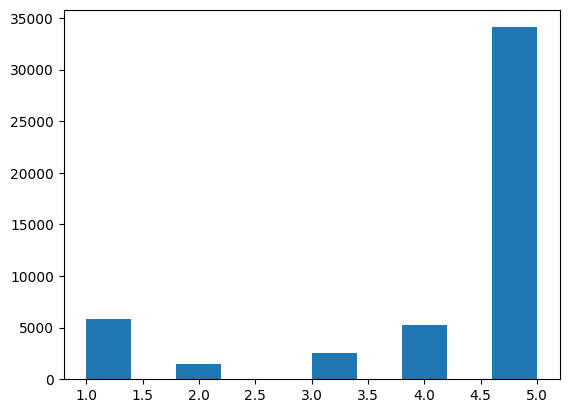

In [10]:
plt.hist(df_result['score'])
plt.show()